In [1]:
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter

INPUT_JSONL = Path("preprocessed_from_disk.jsonl")
OUT_CSV = Path("website_type_overview.csv")

# -------------------------
# Keyword rules
# -------------------------
MARKETPLACE_WORDS = {
    "vendor", "vendors", "escrow", "shipping", "cart", "wallet", "order", "buy",
    "price", "prices", "product", "products", "listing", "listings", "market",
    "marketplace", "btc", "bitcoin", "monero", "payment", "payments", "checkout"
}

FORUM_WORDS = {
    "forum", "thread", "threads", "post", "posts", "reply", "replies", "member",
    "members", "joined", "messages", "message", "discussion", "discussions",
    "board", "boards", "topic", "topics", "signature", "profile"
}

def classify_site(text):
    if not text:
        return "Other"

    txt = str(text).lower()
    words = set(txt.split())

    market_score = sum(1 for w in MARKETPLACE_WORDS if w in words)
    forum_score = sum(1 for w in FORUM_WORDS if w in words)

    if market_score >= 2 and market_score > forum_score:
        return "Marketplace"
    if forum_score >= 2 and forum_score > market_score:
        return "Forum"
    return "Other"

# -------------------------
# Build domain-level evidence
# Prefer root pages when available
# -------------------------
domain_rows = defaultdict(list)

with INPUT_JSONL.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        try:
            rec = json.loads(line)
        except Exception:
            continue

        domain = rec.get("domain_url")
        if not domain:
            continue

        text = rec.get("preprocessed_trafilatura") or rec.get("preprocessed_content") or ""
        title = rec.get("title") or ""
        path = rec.get("path") or ""

        domain_rows[domain].append({
            "title": title,
            "text": text,
            "path": path,
            "snapshot_id": rec.get("snapshot_id"),
            "created_at": rec.get("created_at"),
        })

summary_rows = []

for domain, rows in domain_rows.items():
    # prefer root pages
    root_rows = [r for r in rows if r["path"] == "/"]
    chosen_rows = root_rows if root_rows else rows[:5]

    evidence = " ".join((r["title"] + " " + r["text"]) for r in chosen_rows if r)
    site_type = classify_site(evidence)

    summary_rows.append({
        "domain_url": domain,
        "site_type": site_type,
        "records": len(rows),
        "unique_snapshots": len({r["snapshot_id"] for r in rows if r["snapshot_id"] is not None}),
    })

website_df = pd.DataFrame(summary_rows).sort_values(["site_type", "domain_url"]).reset_index(drop=True)
website_df.to_csv(OUT_CSV, index=False)

print(f"Saved website classification to: {OUT_CSV.resolve()}")
display(website_df["site_type"].value_counts())
display(website_df.head(20))

Saved website classification to: /home/darknet/2026-01-27_201419_domain_with_snapshots/website_type_overview.csv


site_type
Other          16181
Marketplace     7193
Forum           1691
Name: count, dtype: int64

,domain_url,site_type,records,unique_snapshots
0,http://222222xp4u3jf3w6uko56oz7a265gpape6rohl7...,Forum,351,351
1,http://22kpqear6nhhz3nxqn5ogihm3kx3xaxvtlln5fy...,Forum,4,4
2,http://24exe2brfflpgcjz35d2liurf76z6ugamxwmn6j...,Forum,4,4
3,http://25krqna3tdskhxb3af2s4imiu2qcuh3wd26geoj...,Forum,2,2
4,http://26je6ghmttubxa7w24drfhbveu4amsq2qpzviad...,Forum,4,4
5,http://26jlqvpu5dpjxehozsm4kpokl5er3mqbifgpvfy...,Forum,7,7
6,http://2ahgvxgngcdtluxdmltll725yzoari65er23req...,Forum,1,1
7,http://2auw7x466f5jdthlwf3svz2aahwy2j66d2uxykx...,Forum,4,4
8,http://2b7v6iclleanemedaxajj4i52sqy33xd7rwechg...,Forum,1,1
9,http://2damu26wiqtlbnibtxt4ju3k5wxtpkf63spbk3h...,Forum,10,10


In [3]:
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter
from datetime import datetime
import re

INPUT_JSONL = Path("preprocessed_from_disk.jsonl")
OUT_CSV = Path("website_type_overview_improved_min4snapshots.csv")
OUT_SUMMARY_CSV = Path("website_type_summary_improved_min4snapshots.csv")

# -------------------------
# Stronger keyword sets
# -------------------------
MARKETPLACE_WORDS = {
    "vendor": 4, "vendors": 4, "seller": 3, "sellers": 3,
    "escrow": 5, "shipping": 3, "ship": 2, "cart": 5,
    "wallet": 3, "order": 4, "orders": 4, "buy": 2, "sell": 2,
    "price": 2, "prices": 2, "product": 2, "products": 2,
    "listing": 3, "listings": 3, "market": 3, "marketplace": 5,
    "btc": 2, "bitcoin": 2, "xmr": 3, "monero": 3,
    "payment": 3, "payments": 3, "checkout": 5,
    "shop": 4, "stock": 2, "item": 2, "items": 2,
    "customer": 2, "refund": 2, "delivery": 2, "purchase": 2,
    "account": 1, "accounts": 1,
    "add to cart": 5, "buyer protection": 4
}

FORUM_WORDS = {
    "forum": 6, "board": 4, "boards": 4,
    "thread": 5, "threads": 5, "post": 3, "posts": 3,
    "reply": 4, "replies": 4, "member": 3, "members": 3,
    "joined": 3, "messages": 3, "message": 3,
    "discussion": 4, "discussions": 4, "topic": 3, "topics": 3,
    "profile": 3, "signature": 3, "moderator": 4, "admin": 3,
    "new posts": 5, "unread posts": 5, "view forum": 5,
    "last post": 4, "private messages": 5, "registered users": 4,
    "search forum": 4, "member posts": 4
}

def ts_to_str(ts):
    if ts is None or pd.isna(ts):
        return None
    try:
        return datetime.utcfromtimestamp(ts / 1000).strftime("%Y-%m-%d %H:%M:%S")
    except Exception:
        return None

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return normalize_text(text).split()

def score_category(title, text, keyword_map):
    title_norm = normalize_text(title)
    text_norm = normalize_text(text)

    title_tokens = Counter(tokenize(title))
    body_tokens = Counter(tokenize(text))

    score = 0
    for kw, weight in keyword_map.items():
        if " " in kw:
            if kw in title_norm:
                score += weight * 4
            if kw in text_norm:
                score += weight
        else:
            score += title_tokens.get(kw, 0) * weight * 4
            score += body_tokens.get(kw, 0) * weight
    return score

def classify_site_from_rows(rows):
    # prefer root/home pages
    root_rows = [r for r in rows if r["path"] == "/"]
    chosen_rows = root_rows[:5] if root_rows else rows[:5]

    title = " ".join(r["title"] for r in chosen_rows if r["title"])
    text = " ".join(r["text"] for r in chosen_rows if r["text"])

    marketplace_score = score_category(title, text, MARKETPLACE_WORDS)
    forum_score = score_category(title, text, FORUM_WORDS)
    best_score = max(marketplace_score, forum_score)

    # decision rules
    if best_score < 6:
        site_type = "Other"
    elif marketplace_score >= forum_score + 3:
        site_type = "Marketplace"
    elif forum_score >= marketplace_score + 3:
        site_type = "Forum"
    else:
        site_type = "Other"

    return site_type, marketplace_score, forum_score, best_score

# -------------------------
# Build domain-level evidence
# -------------------------
domain_rows = defaultdict(list)

with INPUT_JSONL.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        try:
            rec = json.loads(line)
        except Exception:
            continue

        domain = rec.get("domain_url")
        if not domain:
            continue

        text = rec.get("preprocessed_trafilatura") or rec.get("preprocessed_content") or ""
        title = rec.get("title") or ""
        path = rec.get("path") or ""

        domain_rows[domain].append({
            "title": title,
            "text": text,
            "path": path,
            "snapshot_id": rec.get("snapshot_id"),
            "created_at": rec.get("created_at"),
        })

# -------------------------
# Classify only websites with >= 4 snapshots
# -------------------------
summary_rows = []

for domain, rows in domain_rows.items():
    snapshot_ids = {r["snapshot_id"] for r in rows if r["snapshot_id"] is not None}

    if len(snapshot_ids) < 4:
        continue

    site_type, marketplace_score, forum_score, best_score = classify_site_from_rows(rows)
    created_vals = [r["created_at"] for r in rows if r["created_at"] is not None]

    summary_rows.append({
        "domain_url": domain,
        "site_type": site_type,
        "marketplace_score": marketplace_score,
        "forum_score": forum_score,
        "classification_score": best_score,
        "records": len(rows),
        "unique_snapshots": len(snapshot_ids),
        "first_seen": ts_to_str(min(created_vals)) if created_vals else None,
        "last_seen": ts_to_str(max(created_vals)) if created_vals else None,
    })

website_df = pd.DataFrame(summary_rows).sort_values(
    ["site_type", "classification_score", "unique_snapshots", "domain_url"],
    ascending=[True, False, False, True]
).reset_index(drop=True)

website_df.to_csv(OUT_CSV, index=False)

# -------------------------
# Aggregate summary
# -------------------------
site_type_summary = (
    website_df.groupby("site_type", as_index=False)
    .agg(
        websites=("domain_url", "count"),
        total_records=("records", "sum"),
        total_unique_snapshots=("unique_snapshots", "sum"),
        avg_snapshots_per_website=("unique_snapshots", "mean"),
        median_snapshots_per_website=("unique_snapshots", "median"),
        max_snapshots_for_one_website=("unique_snapshots", "max"),
        avg_marketplace_score=("marketplace_score", "mean"),
        avg_forum_score=("forum_score", "mean"),
    )
    .sort_values("websites", ascending=False)
    .reset_index(drop=True)
)

site_type_summary["avg_snapshots_per_website"] = site_type_summary["avg_snapshots_per_website"].round(2)
site_type_summary["avg_marketplace_score"] = site_type_summary["avg_marketplace_score"].round(2)
site_type_summary["avg_forum_score"] = site_type_summary["avg_forum_score"].round(2)

site_type_summary.to_csv(OUT_SUMMARY_CSV, index=False)

print(f"Saved website classification to: {OUT_CSV.resolve()}")
print(f"Saved summary to: {OUT_SUMMARY_CSV.resolve()}")

print("\nTotal websites after filtering (>= 4 snapshots):", len(website_df))

print("\nCounts by site type:")
display(website_df["site_type"].value_counts())

print("\nSummary:")
display(site_type_summary)

print("\nTop marketplaces by score:")
display(
    website_df[website_df["site_type"] == "Marketplace"]
    .sort_values(["marketplace_score", "unique_snapshots"], ascending=[False, False])
    .head(20)
)

print("\nTop forums by score:")
display(
    website_df[website_df["site_type"] == "Forum"]
    .sort_values(["forum_score", "unique_snapshots"], ascending=[False, False])
    .head(20)
)

print("\nSample output:")
display(website_df.head(20))

/tmp/ipykernel_169930/1484396768.py:45: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts / 1000).strftime("%Y-%m-%d %H:%M:%S")


Saved website classification to: /home/darknet/2026-01-27_201419_domain_with_snapshots/website_type_overview_improved_min4snapshots.csv
Saved summary to: /home/darknet/2026-01-27_201419_domain_with_snapshots/website_type_summary_improved_min4snapshots.csv

Total websites after filtering (>= 4 snapshots): 16037

Counts by site type:


site_type
Marketplace    10830
Other           3747
Forum           1460
Name: count, dtype: int64


Summary:


,site_type,websites,total_records,total_unique_snapshots,avg_snapshots_per_website,median_snapshots_per_website,max_snapshots_for_one_website,avg_marketplace_score,avg_forum_score
0,Marketplace,10830,4735308,4735308,437.24,13.0,358848,96.68,7.70
1,Other,3747,1329236,1329236,354.75,6.0,128442,0.87,0.38
2,Forum,1460,5328443,5328443,3649.62,4.0,105342,12.25,85.02


...

,domain_url,site_type,marketplace_score,forum_score,classification_score,records,unique_snapshots,first_seen,last_seen
1460,http://5ryuwdqvqv5mhy57sb2gnfrxlpebezy65ck3gqn...,Marketplace,26442,0,26442,4,4,2020-08-24 03:29:26,2026-01-13 01:09:54
1461,http://wsdzzjvdvkpql63rwnnjcaci5xvkob2f5wyjcg7...,Marketplace,6156,1551,6156,477,477,2021-12-19 03:23:20,2024-03-12 11:46:18
1462,http://walletsxvjg3xiuxayfk56e6bt4adk5dl7njuy3...,Marketplace,5705,0,5705,4555,4555,2022-01-05 09:31:06,2024-06-10 20:57:19
1463,http://wsdzzjvv5wne2hffn3y5bpvwdaarnoiygggwpu7...,Marketplace,4386,1152,4386,190,190,2024-03-08 07:53:30,2024-12-12 08:55:46
1464,http://legit5keqtyff6n7wpsag2ikvshwohjm7masz2x...,Marketplace,3683,0,3683,5702,5702,2022-10-13 18:02:13,2023-10-16 11:29:55
1465,http://keybuygglif47kwzic7wbb56ihokc2bajpl7d6u...,Marketplace,3385,0,3385,7,7,2023-12-28 08:49:35,2026-01-30 02:15:28
1466,http://zhop23asynppwfm7.onion,Marketplace,2664,0,2664,4,4,2020-06-08 04:04:37,2020-07-15 09:43:50
1467,http://bsteal7i7gy7pdq6iwcbjsfg7chen3wezhjzrm5...,Marketplace,2615,0,2615,428,428,2022-02-18 16:22:01,2026-01-26 21:12:30
1468,http://kcqtxvp2fkojaxan7atgdauz5unydvf6sbiz2sz...,Marketplace,2538,0,2538,4,4,2022-04-17 07:51:06,2022-07-04 07:57:02
1469,http://tq73adojg77ptpbi25ywzhqyrsn3btxu3gr4h3g...,Marketplace,2535,0,2535,59,59,2025-12-11 09:46:20,2026-01-29 08:01:51



Top forums by score:


,domain_url,site_type,marketplace_score,forum_score,classification_score,records,unique_snapshots,first_seen,last_seen
0,http://ky6urnzorg43zp5sw2gb46csndhpzn6ttpectme...,Forum,50,4984,4984,4495,4495,2024-10-20 03:29:20,2025-11-23 22:49:51
1,https://ky6urnzorg43zp5sw2gb46csndhpzn6ttpectm...,Forum,50,4975,4975,4257,4257,2024-10-20 03:33:36,2025-11-24 00:59:05
2,http://zerodaxtgasp6sbl2bi6trvwm6rzfzbx5rvswba...,Forum,174,2746,2746,127,127,2023-12-18 17:13:11,2024-05-12 11:30:33
3,http://zerodayfm4fvyogxyyrlrlxv7jf7u3q5pbo2iay...,Forum,205,2743,2743,1299,1299,2024-03-08 08:20:14,2024-08-14 18:54:28
4,http://zerodayhukmtc56zualcmtvtto5xfz7gytgt7po...,Forum,206,2648,2648,11498,11498,2023-09-19 07:00:26,2024-06-23 01:56:31
5,http://raidingbbnkptrmgk6qrvd74ziatxsikzqsa3ek...,Forum,70,2431,2431,47,47,2023-08-24 19:04:08,2023-10-04 10:28:28
6,http://dbuhrrgn4kt7zmvjoavo25bfhmae4lome4dmcy3...,Forum,70,2169,2169,2006,2006,2024-06-12 06:11:03,2024-06-28 21:32:09
7,http://pxguzx4iisdryzpfnefy34ls65bex5hv7ogst6e...,Forum,74,2079,2079,3160,3160,2024-09-20 14:16:29,2024-10-29 03:28:33
8,http://wzxwaenviyszsibzjl6kvikavyrkng26cmsr6dn...,Forum,70,2079,2079,1335,1335,2024-03-16 01:59:48,2024-06-25 20:38:51
9,http://w5tnhtn5wm7o3nbs2d33myouokylxbropp4y3kq...,Forum,79,2070,2070,3033,3033,2024-07-07 06:11:44,2024-08-20 22:55:37



Sample output:


,domain_url,site_type,marketplace_score,forum_score,classification_score,records,unique_snapshots,first_seen,last_seen
0,http://ky6urnzorg43zp5sw2gb46csndhpzn6ttpectme...,Forum,50,4984,4984,4495,4495,2024-10-20 03:29:20,2025-11-23 22:49:51
1,https://ky6urnzorg43zp5sw2gb46csndhpzn6ttpectm...,Forum,50,4975,4975,4257,4257,2024-10-20 03:33:36,2025-11-24 00:59:05
2,http://zerodaxtgasp6sbl2bi6trvwm6rzfzbx5rvswba...,Forum,174,2746,2746,127,127,2023-12-18 17:13:11,2024-05-12 11:30:33
3,http://zerodayfm4fvyogxyyrlrlxv7jf7u3q5pbo2iay...,Forum,205,2743,2743,1299,1299,2024-03-08 08:20:14,2024-08-14 18:54:28
4,http://zerodayhukmtc56zualcmtvtto5xfz7gytgt7po...,Forum,206,2648,2648,11498,11498,2023-09-19 07:00:26,2024-06-23 01:56:31
5,http://raidingbbnkptrmgk6qrvd74ziatxsikzqsa3ek...,Forum,70,2431,2431,47,47,2023-08-24 19:04:08,2023-10-04 10:28:28
6,http://dbuhrrgn4kt7zmvjoavo25bfhmae4lome4dmcy3...,Forum,70,2169,2169,2006,2006,2024-06-12 06:11:03,2024-06-28 21:32:09
7,http://pxguzx4iisdryzpfnefy34ls65bex5hv7ogst6e...,Forum,74,2079,2079,3160,3160,2024-09-20 14:16:29,2024-10-29 03:28:33
8,http://wzxwaenviyszsibzjl6kvikavyrkng26cmsr6dn...,Forum,70,2079,2079,1335,1335,2024-03-16 01:59:48,2024-06-25 20:38:51
9,http://w5tnhtn5wm7o3nbs2d33myouokylxbropp4y3kq...,Forum,79,2070,2070,3033,3033,2024-07-07 06:11:44,2024-08-20 22:55:37


Detected delimiter for labels file: ';'
Website rows: 16037
Metadata rows: 7381762
Reduced assignments in model: 7381762
Expanded label rows: 84
Merged usable rows: 6528747


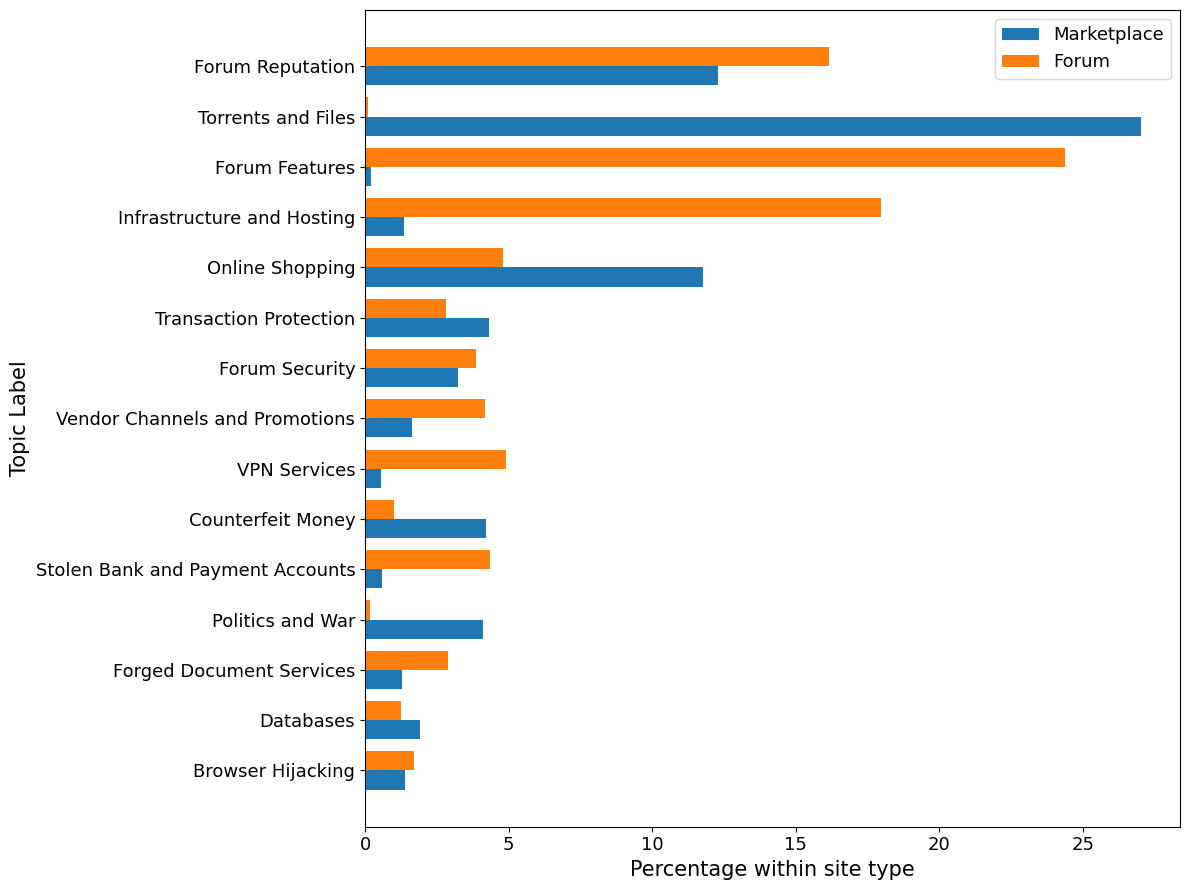

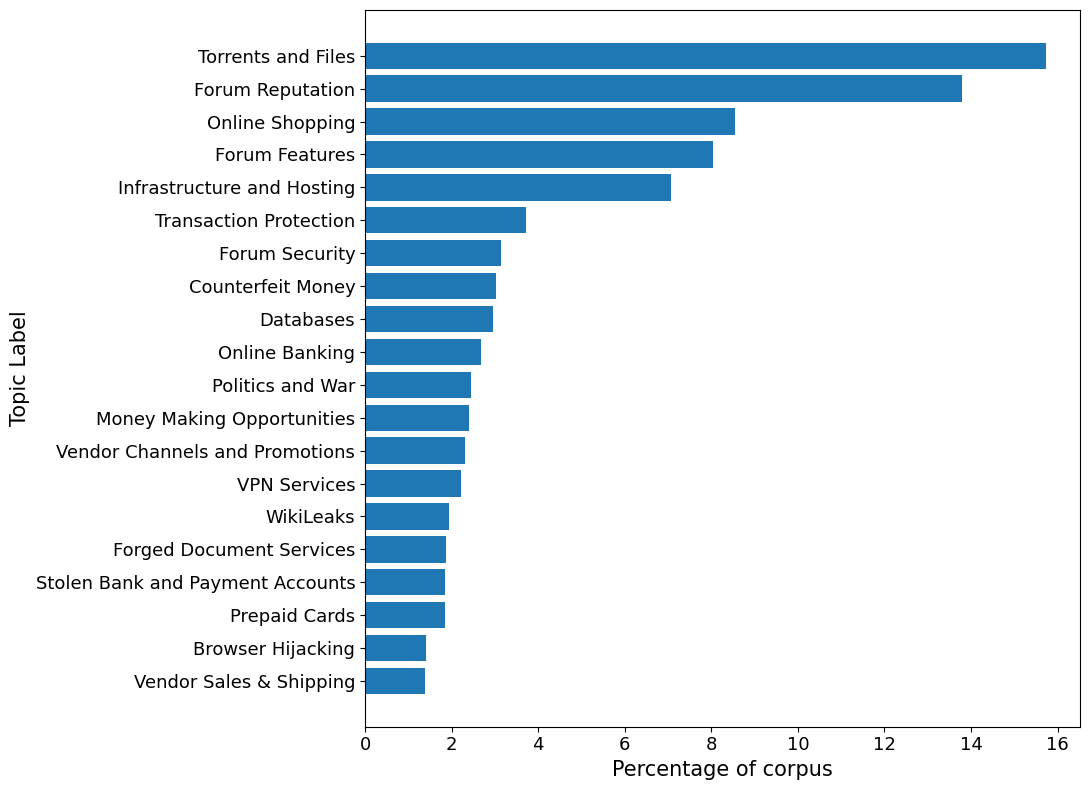

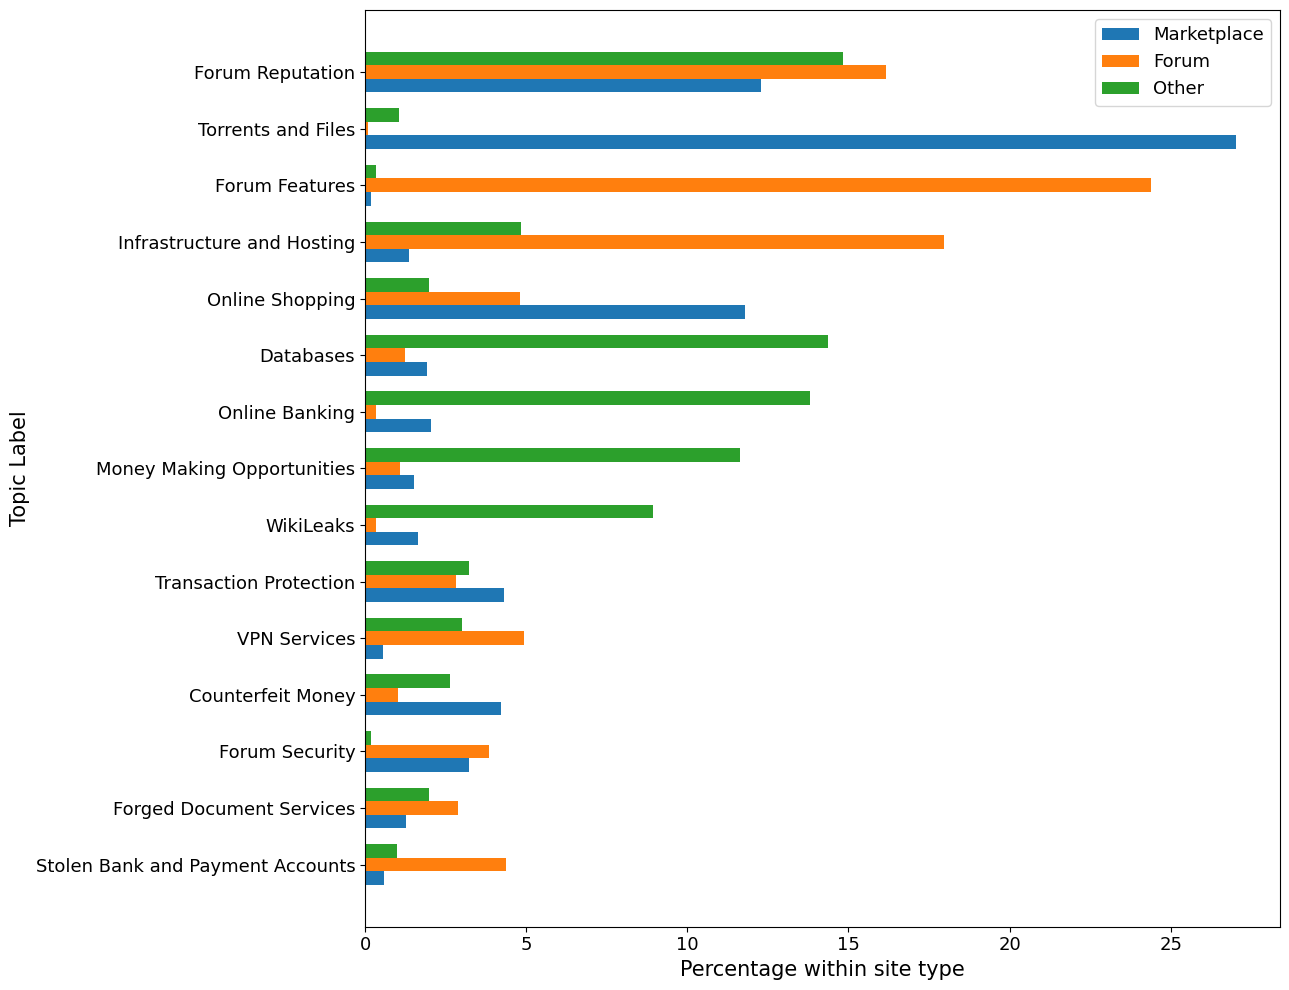


Saved Marketplace table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_900_90_marketplace_topics.csv
Saved Forum table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_900_90_forum_topics.csv
Saved Other table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_900_90_other_topics.csv
Saved comparison table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_900_90_marketplace_vs_forum_comparison.csv
Saved three-way comparison table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_900_90_marketplace_forum_other_comparison.csv
Saved overall composition table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_900_90_overall_grouped_topics.csv
Saved comparison figure to: /home/darknet/2026-01-27_201419_domain_with_snapshots/DarkBERT/darkbert_900_90_marketplace_vs_forum.pdf
Saved overall composition figure to: /home/darknet/2026-01-27_

,site_type,Final,Count,Keywords,% within site_type
0,Marketplace,Torrents and Files,1017737,"torrent kib, txt kib, kib november, txt mib, z...",27.04
1,Marketplace,Forum Reputation,462355,"golden member, message reaction, following rea...",12.29
2,Marketplace,Online Shopping,443585,"buyed product, product paypal, product visa, g...",11.79
3,Marketplace,Transaction Protection,162389,"paypal true, buyer protection, parcel guide, p...",4.32
4,Marketplace,Counterfeit Money,159006,"electronics porn, countersurveillance btc, ban...",4.23
5,Marketplace,Politics and War,154575,"politics world, war problem, question answer, ...",4.11
6,Marketplace,Forum Security,121911,"forum new, new search, search forum, javascrip...",3.24
7,Marketplace,Prepaid Cards,110772,"republic congo, vendor mastercard, money atm, ...",2.94
8,Marketplace,Credit Card Data,84909,"balance vendor, credit card, buyer protection,...",2.26
9,Marketplace,Online Banking,77645,"categorycarding statusonline, item category, u...",2.06



Top Forum grouped labels:


,site_type,Final,Count,Keywords,% within site_type
0,Forum,Forum Features,514373,"forum new, browser forum, new search, member p...",24.40
1,Forum,Infrastructure and Hosting,378612,"url server, debian server, server apache, tor ...",17.96
2,Forum,Forum Reputation,340661,"golden member, message reaction, following rea...",16.16
3,Forum,VPN Services,103832,"free vpn, com january, view august, warrior au...",4.92
4,Forum,Online Shopping,101228,"buyed product, product paypal, product visa, g...",4.80
5,Forum,Stolen Bank and Payment Accounts,91933,"bank america, payoneer onefinance, paypal bank...",4.36
6,Forum,Vendor Channels and Promotions,87869,"channel onlyfapcity, joined january, january m...",4.17
7,Forum,Forum Security,81369,"forum new, new search, search forum, javascrip...",3.86
8,Forum,Forged Document Services,61106,"soul_service vendor, customer trace, request p...",2.90
9,Forum,Transaction Protection,59513,"paypal true, buyer protection, parcel guide, p...",2.82



Top Other grouped labels:


...

,Final,Count_Marketplace,% within site_type_Marketplace,Count_Forum,% within site_type_Forum,Difference
0,Torrents and Files,1017737.0,27.04,2194.0,0.10,26.94
1,Online Shopping,443585.0,11.79,101228.0,4.80,6.99
2,Politics and War,154575.0,4.11,4071.0,0.19,3.92
3,Counterfeit Money,159006.0,4.23,21526.0,1.02,3.21
4,Prepaid Cards,110772.0,2.94,2315.0,0.11,2.83
5,Credit Card Data,84909.0,2.26,1503.0,0.07,2.19
6,Online Banking,77645.0,2.06,7225.0,0.34,1.72
7,PayPal Scams,68913.0,1.83,3679.0,0.17,1.66
8,Exposed Website Directories,63491.0,1.69,3081.0,0.15,1.54
9,Transaction Protection,162389.0,4.32,59513.0,2.82,1.50



Labels more common in Forums:


,Final,Count_Marketplace,% within site_type_Marketplace,Count_Forum,% within site_type_Forum,Difference
54,Forum Features,7375.0,0.20,514373.0,24.40,-24.20
53,Infrastructure and Hosting,50780.0,1.35,378612.0,17.96,-16.61
52,VPN Services,21340.0,0.57,103832.0,4.92,-4.35
51,Forum Reputation,462355.0,12.29,340661.0,16.16,-3.87
50,Stolen Bank and Payment Accounts,22588.0,0.60,91933.0,4.36,-3.76
49,Vendor Channels and Promotions,62074.0,1.65,87869.0,4.17,-2.52
48,Forged Document Services,48091.0,1.28,61106.0,2.90,-1.62
47,Rocksolid Newsreader,3697.0,0.10,34213.0,1.62,-1.52
46,Hidden Content and Access Links,6429.0,0.17,23163.0,1.10,-0.93
45,Forum Security,121911.0,3.24,81369.0,3.86,-0.62



Three-way comparison:


,Final,% Marketplace,% Forum,% Other,Combined
0,Forum Reputation,12.29,16.16,14.83,43.28
1,Torrents and Files,27.04,0.10,1.05,28.19
2,Forum Features,0.20,24.40,0.35,24.95
3,Infrastructure and Hosting,1.35,17.96,4.83,24.14
4,Online Shopping,11.79,4.80,1.99,18.58
5,Databases,1.92,1.24,14.36,17.52
6,Online Banking,2.06,0.34,13.81,16.21
7,Money Making Opportunities,1.52,1.09,11.64,14.25
8,WikiLeaks,1.63,0.34,8.95,10.92
9,Transaction Protection,4.32,2.82,3.22,10.36


In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from pathlib import Path

# -------------------------
# Fix for loading saved model with custom reducer
# -------------------------
class IdentityReducer:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        return X


# -------------------------
# PATHS
# -------------------------
WEBSITE_TYPES = Path("website_type_overview_improved_min4snapshots.csv")
DOC_META_PATH = Path("./DarkBERT/output_darkbert__900_90/doc_topics.csv")   # metadata source only
MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/final_labeling.csv")

OUT_MARKETPLACE = Path("./DarkBERT/darkbert_900_90_marketplace_topics.csv")
OUT_FORUM = Path("./DarkBERT/darkbert_900_90_forum_topics.csv")
OUT_OTHER = Path("./DarkBERT/darkbert_900_90_other_topics.csv")
OUT_COMPARISON = Path("./DarkBERT/darkbert_900_90_marketplace_vs_forum_comparison.csv")
OUT_OVERALL = Path("./DarkBERT/darkbert_900_90_overall_grouped_topics.csv")
OUT_THREEWAY = Path("./DarkBERT/darkbert_900_90_marketplace_forum_other_comparison.csv")

FIG_COMPARE = Path("./DarkBERT/darkbert_900_90_marketplace_vs_forum.pdf")
FIG_OVERALL = Path("./DarkBERT/darkbert_900_90_overall_ecosystem_composition.pdf")
FIG_THREEWAY = Path("./DarkBERT/darkbert_900_90_marketplace_forum_other.pdf")

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# -------------------------
# FONT SIZES
# -------------------------
LABEL_FONTSIZE = 15
TICK_FONTSIZE = 13
LEGEND_FONTSIZE = 13


# -------------------------
# Helper: detect delimiter
# -------------------------
def detect_delimiter(path: Path) -> str:
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        first_line = f.readline()
    return ";" if first_line.count(";") > first_line.count(",") else ","


# -------------------------
# Helper: load grouped labels
# Expands grouped Topic_ID values like "3,7,12"
# but later aggregation is by Final, so grouped topics stay grouped
# -------------------------
def load_grouped_labels_csv(path: Path) -> pd.DataFrame:
    rows = []
    delimiter = detect_delimiter(path)
    print(f"Detected delimiter for labels file: {repr(delimiter)}")

    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f, delimiter=delimiter)

        fieldnames = [name.strip() for name in (reader.fieldnames or [])]
        expected = {"Topic_ID", "Final"}
        missing = expected - set(fieldnames)
        if missing:
            raise ValueError(
                f"Missing required columns in labels file: {missing}\n"
                f"Detected fieldnames: {fieldnames}"
            )

        for raw_row in reader:
            row = {(k.strip() if k else k): v for k, v in raw_row.items()}

            topic_id_raw = (row.get("Topic_ID") or "").strip()
            final_raw = (row.get("Final") or "").strip()
            keywords_raw = (row.get("Keywords") or "").strip() if "Keywords" in row else ""

            if not topic_id_raw:
                continue

            topic_ids = [x.strip() for x in topic_id_raw.split(",") if x.strip()]

            for tid in topic_ids:
                if tid.isdigit():
                    rows.append({
                        "Topic": int(tid),
                        "Final": final_raw,
                        "Keywords": keywords_raw,
                        "Grouped_Topic_ID": topic_id_raw,
                    })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("No topic rows were parsed from final_labeling.csv.")

    return df


# -------------------------
# LOAD DATA
# -------------------------
website_df = pd.read_csv(WEBSITE_TYPES)
doc_meta = pd.read_csv(DOC_META_PATH)         # use for domain_url and metadata only
topic_model = BERTopic.load(MODEL_PATH)
labels_df = load_grouped_labels_csv(LABELS_PATH)

print("Website rows:", len(website_df))
print("Metadata rows:", len(doc_meta))
print("Reduced assignments in model:", len(topic_model.topics_))
print("Expanded label rows:", len(labels_df))


# -------------------------
# Replace pre-reduction topic column with reduced assignments from model
# -------------------------
if len(doc_meta) != len(topic_model.topics_):
    raise ValueError(
        f"Length mismatch: doc_meta has {len(doc_meta)} rows but model has {len(topic_model.topics_)} topic assignments."
    )

doc_meta = doc_meta.copy()
doc_meta["Topic"] = topic_model.topics_   # final reduced topic assignments


# -------------------------
# Keep Marketplace, Forum, Other
# -------------------------
website_df = website_df[website_df["site_type"].isin(["Marketplace", "Forum", "Other"])].copy()


# -------------------------
# Merge metadata with site type
# -------------------------
merged = doc_meta.merge(
    website_df[["domain_url", "site_type"]],
    on="domain_url",
    how="inner"
)

# remove outliers
merged = merged[merged["Topic"] != -1].copy()


# -------------------------
# Merge grouped final labels
# -------------------------
merged = merged.merge(
    labels_df[["Topic", "Final", "Keywords"]],
    on="Topic",
    how="left"
)

merged["Final"] = merged["Final"].fillna("Unlabeled Topic")
merged["Keywords"] = merged["Keywords"].fillna("")

print("Merged usable rows:", len(merged))


# -------------------------
# Aggregate per site type and grouped final label
# -------------------------
summary = (
    merged.groupby(["site_type", "Final"], as_index=False)
    .agg(
        Count=("Topic", "size"),
        Keywords=("Keywords", lambda x: " | ".join(sorted(set(v for v in x if str(v).strip()))))
    )
)

summary["% within site_type"] = (
    summary.groupby("site_type")["Count"]
    .transform(lambda s: 100 * s / s.sum())
).round(2)


marketplace_topics = (
    summary[summary["site_type"] == "Marketplace"]
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

forum_topics = (
    summary[summary["site_type"] == "Forum"]
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

other_topics = (
    summary[summary["site_type"] == "Other"]
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

marketplace_topics.to_csv(OUT_MARKETPLACE, sep=";", index=False, encoding="utf-8-sig")
forum_topics.to_csv(OUT_FORUM, sep=";", index=False, encoding="utf-8-sig")
other_topics.to_csv(OUT_OTHER, sep=";", index=False, encoding="utf-8-sig")


# -------------------------
# Side-by-side comparison table: Marketplace vs Forum
# -------------------------
comparison = pd.merge(
    marketplace_topics[["Final", "Count", "% within site_type"]],
    forum_topics[["Final", "Count", "% within site_type"]],
    on="Final",
    how="outer",
    suffixes=("_Marketplace", "_Forum")
).fillna(0)

comparison["Difference"] = (
    comparison["% within site_type_Marketplace"] -
    comparison["% within site_type_Forum"]
).round(2)

comparison = comparison.sort_values("Difference", ascending=False).reset_index(drop=True)
comparison.to_csv(OUT_COMPARISON, sep=";", index=False, encoding="utf-8-sig")


# -------------------------
# Three-way comparison table: Marketplace vs Forum vs Other
# -------------------------
threeway = marketplace_topics[["Final", "% within site_type"]].rename(
    columns={"% within site_type": "% Marketplace"}
)

threeway = threeway.merge(
    forum_topics[["Final", "% within site_type"]].rename(
        columns={"% within site_type": "% Forum"}
    ),
    on="Final",
    how="outer"
)

threeway = threeway.merge(
    other_topics[["Final", "% within site_type"]].rename(
        columns={"% within site_type": "% Other"}
    ),
    on="Final",
    how="outer"
).fillna(0)

threeway["Combined"] = threeway["% Marketplace"] + threeway["% Forum"] + threeway["% Other"]
threeway = threeway.sort_values("Combined", ascending=False).reset_index(drop=True)
threeway.to_csv(OUT_THREEWAY, sep=";", index=False, encoding="utf-8-sig")


# -------------------------
# Overall ecosystem composition across Marketplace+Forum+Other
# -------------------------
overall = (
    merged.groupby("Final", as_index=False)
    .agg(
        Count=("Topic", "size"),
        Keywords=("Keywords", lambda x: " | ".join(sorted(set(v for v in x if str(v).strip()))))
    )
)

overall["% of Corpus"] = (100 * overall["Count"] / overall["Count"].sum()).round(2)
overall = overall.sort_values("% of Corpus", ascending=False).reset_index(drop=True)
overall.to_csv(OUT_OVERALL, sep=";", index=False, encoding="utf-8-sig")


# -------------------------
# CHART 1: Marketplace vs Forum comparison
# -------------------------
plot_compare = pd.merge(
    marketplace_topics[["Final", "% within site_type"]],
    forum_topics[["Final", "% within site_type"]],
    on="Final",
    how="outer",
    suffixes=("_Marketplace", "_Forum")
).fillna(0)

plot_compare["Combined"] = (
    plot_compare["% within site_type_Marketplace"] +
    plot_compare["% within site_type_Forum"]
)

TOP_N_COMPARE = 15
plot_compare = (
    plot_compare.sort_values("Combined", ascending=False)
    .head(TOP_N_COMPARE)
    .sort_values("Combined", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 9))
y = range(len(plot_compare))
bar_h = 0.38

ax.barh(
    [i - bar_h/2 for i in y],
    plot_compare["% within site_type_Marketplace"],
    height=bar_h,
    label="Marketplace"
)

ax.barh(
    [i + bar_h/2 for i in y],
    plot_compare["% within site_type_Forum"],
    height=bar_h,
    label="Forum"
)

ax.set_yticks(list(y))
ax.set_yticklabels(plot_compare["Final"], fontsize=TICK_FONTSIZE)
ax.set_xlabel("Percentage within site type", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Topic Label", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis="x", labelsize=TICK_FONTSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.savefig(FIG_COMPARE, bbox_inches="tight")
plt.show()


# -------------------------
# CHART 2: Overall ecosystem composition
# -------------------------
TOP_N_OVERALL = 20
plot_overall = overall.head(TOP_N_OVERALL).sort_values("% of Corpus", ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_overall["Final"], plot_overall["% of Corpus"])
ax.set_xlabel("Percentage of corpus", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Topic Label", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis="x", labelsize=TICK_FONTSIZE)
ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)
plt.tight_layout()
plt.savefig(FIG_OVERALL, bbox_inches="tight")
plt.show()


# -------------------------
# CHART 3: Marketplace vs Forum vs Other
# -------------------------
TOP_N_THREEWAY = 15
plot_threeway = (
    threeway.sort_values("Combined", ascending=False)
    .head(TOP_N_THREEWAY)
    .sort_values("Combined", ascending=True)
)

fig, ax = plt.subplots(figsize=(13, 10))
y = range(len(plot_threeway))
bar_h = 0.24

ax.barh(
    [i - bar_h for i in y],
    plot_threeway["% Marketplace"],
    height=bar_h,
    label="Marketplace"
)

ax.barh(
    [i for i in y],
    plot_threeway["% Forum"],
    height=bar_h,
    label="Forum"
)

ax.barh(
    [i + bar_h for i in y],
    plot_threeway["% Other"],
    height=bar_h,
    label="Other"
)

ax.set_yticks(list(y))
ax.set_yticklabels(plot_threeway["Final"], fontsize=TICK_FONTSIZE)
ax.set_xlabel("Percentage within site type", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Topic Label", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis="x", labelsize=TICK_FONTSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.savefig(FIG_THREEWAY, bbox_inches="tight")
plt.show()


# -------------------------
# Display outputs
# -------------------------
print(f"\nSaved Marketplace table to: {OUT_MARKETPLACE.resolve()}")
print(f"Saved Forum table to: {OUT_FORUM.resolve()}")
print(f"Saved Other table to: {OUT_OTHER.resolve()}")
print(f"Saved comparison table to: {OUT_COMPARISON.resolve()}")
print(f"Saved three-way comparison table to: {OUT_THREEWAY.resolve()}")
print(f"Saved overall composition table to: {OUT_OVERALL.resolve()}")
print(f"Saved comparison figure to: {FIG_COMPARE.resolve()}")
print(f"Saved overall composition figure to: {FIG_OVERALL.resolve()}")
print(f"Saved three-way figure to: {FIG_THREEWAY.resolve()}")

print("\nTop Marketplace grouped labels:")
display(marketplace_topics.head(20))

print("\nTop Forum grouped labels:")
display(forum_topics.head(20))

print("\nTop Other grouped labels:")
display(other_topics.head(20))

print("\nOverall ecosystem composition:")
display(overall.head(20))

print("\nLabels more common in Marketplaces:")
display(comparison.head(20))

print("\nLabels more common in Forums:")
display(comparison.tail(20).sort_values("Difference"))

print("\nThree-way comparison:")
display(threeway.head(20))